\date{}


# Diffusion non linéaire et influence du paramètre $\beta$  
### Application à un modèle simplifié de croissance tumorale

Objectif : implémenter pas à pas un schéma volumes finis implicite en 1D pour l’équation de diffusion rapide,
et étudier le comportement des entropies discrètes au cours du temps.


## Imports et paramètres globaux

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# Paramètres globaux
# ======================

beta = 0.5          # cas de base : diffusion rapide (β = 1/2)
L = 2.0             # longueur du domaine [-1,1]
N = 200             # nombre de volumes de contrôle
dx = L / N
T = 0.1             # temps final
dt = 2e-4
M = int(T / dt)     # nombre de pas de temps

# Grille : centres de mailles sur [-1,1]
x = -1.0 + (np.arange(N) + 0.5) * dx

print(f"N = {N}, dx = {dx:.5f}, dt = {dt}, M = {M}")


N = 200, dx = 0.01000, dt = 0.0002, M = 500


## Commentaire : Paramètres globaux et discrétisation spatiale

On considère l’équation de diffusion non linéaire en dimension 1 :

$$
u_t = \partial_{xx}(u^\beta),
$$

sur l’intervalle $[-1,1]$ avec conditions de Neumann homogènes.

Les paramètres numériques sont :

- $N = 200$ : nombre de mailles du maillage,
- $dx = \dfrac{L}{N} = 0.01$ : pas spatial,
- $dt = 2 \times 10^{-4}$ : pas de temps,
- $T = 0.1$ : temps final,
- $M = 500$ : nombre total de pas de temps,
- $\beta = 0.5$ : régime de diffusion rapide.

La grille spatiale est définie aux **centres des volumes finis**, ce qui est cohérent avec un schéma de type volumes finis.

On travaille ici dans le régime de *fast diffusion* car $\beta < 1$.

## Condition initiale + intégrale sur [-1,1]

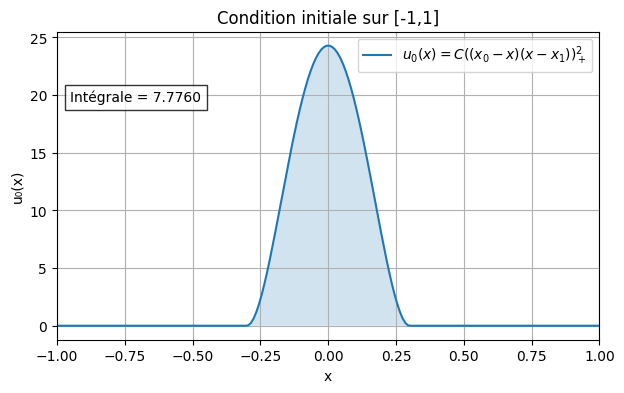

In [2]:
# ======================
# Condition initiale u0
# ======================

def u0(x, x0=-0.3, x1=0.3, C=3000.0):
    z = (x0 - x) * (x - x1)
    z = np.maximum(z, 0.0)
    return C * z**2

u_init = u0(x)

# Intégrale numérique de u0 sur [-1,1]
integrale_u0 = np.trapz(u_init, x)

plt.figure(figsize=(7,4))
plt.plot(x, u_init, label=r"$u_0(x) = C((x_0-x)(x-x_1))_+^2$")
plt.fill_between(x, u_init, alpha=0.2)
plt.xlim([-1, 1])
plt.xlabel("x")
plt.ylabel("u₀(x)")
plt.title("Condition initiale sur [-1,1]")
plt.grid(True)
plt.text(-0.95, 0.8*np.max(u_init),
         f"Intégrale = {integrale_u0:.4f}",
         bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.show()


## Commentaire : Condition initiale

La condition initiale est définie comme :

$$
u_0(x) = C \left( (x_0 - x)(x - x_1) \right)_+^2,
\quad \text{avec } x_0 = -0.3,\; x_1 = 0.3.
$$

Cette fonction possède les propriétés suivantes :

- $u_0(x) \ge 0$ pour tout $x$,
- $u_0(x) = 0$ hors de l’intervalle $[-0.3,0.3]$,
- $u_0$ est symétrique par rapport à $x = 0$,
- $u_0$ modélise une bosse localisée représentant une concentration initiale.

On calcule ensuite la masse initiale :

$$
M(0) = \int_{-1}^{1} u_0(x)\,dx.
$$

Numériquement, on obtient :

$$
M(0) \approx 7.776,
$$

ce qui coïncide avec la valeur analytique :

$$
\int u_0(x)\,dx = \frac{C (x_1 - x_0)^5}{30} = 7.776.
$$

Cela valide la discrétisation spatiale et le calcul numérique de l’intégrale.


## Schéma implicite : Newton + tridiagonale

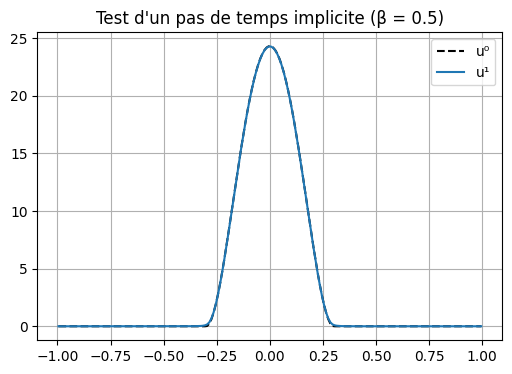

In [3]:
# ============================================
# Schéma Euler implicite + Newton en 1D
# ============================================

def residual_and_jacobian(u_new, u_old, beta, dx, dt, eps=1e-12):
    """
    Construit :
    - le résidu R(u_new)
    - les diagonales de la matrice jacobienne (tridiagonale)
    Schéma FV implicite pour u_t = (u^β)_xx avec Neumann.
    """
    N = u_new.size
    D = dt / dx**2
    
    r = np.zeros(N)
    main = np.ones(N)
    lower = np.zeros(N-1)
    upper = np.zeros(N-1)
    
    # éviter les puissances sur des valeurs négatives
    u_eps = np.maximum(u_new, 0.0) + eps
    pow_beta = u_eps**beta
    d_beta = beta * u_eps**(beta - 1.0)
    
    # Bord gauche (Neumann)
    r[0] = u_new[0] - u_old[0] + D*(pow_beta[0] - pow_beta[1])
    main[0] = 1.0 + D*d_beta[0]
    upper[0] = -D*d_beta[1]
    
    # Cellules intérieures
    for i in range(1, N-1):
        r[i] = u_new[i] - u_old[i] + D*(2*pow_beta[i] - pow_beta[i-1] - pow_beta[i+1])
        main[i] = 1.0 + 2*D*d_beta[i]
        lower[i-1] = -D*d_beta[i-1]
        upper[i]   = -D*d_beta[i+1]
    
    # Bord droit (Neumann)
    r[N-1] = u_new[N-1] - u_old[N-1] + D*(pow_beta[N-1] - pow_beta[N-2])
    main[N-1] = 1.0 + D*d_beta[N-1]
    lower[N-2] = -D*d_beta[N-2]
    
    return r, main, lower, upper


def solve_tridiag(main, lower, upper, rhs):
    """Solve un système tridiagonal par l'algorithme de Thomas."""
    n = len(main)
    a = lower.copy()
    b = main.copy()
    c = upper.copy()
    d = rhs.copy()
    # forward
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i] -= w*c[i-1]
        d[i] -= w*d[i-1]
    # backward
    x = np.zeros_like(d)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x


def one_time_step(u_old, beta, dx, dt, max_iter=50, tol=1e-10, damping=0.5):
    """Effectue un pas d'Euler implicite avec Newton amorti."""
    u_new = u_old.copy()
    for it in range(max_iter):
        r, main, lower, upper = residual_and_jacobian(u_new, u_old, beta, dx, dt)
        norm_r = np.linalg.norm(r, np.inf)
        if norm_r < tol:
            break
        delta = solve_tridiag(main, lower, upper, -r)
        # amortissement + projection sur ℝ⁺
        u_new = np.maximum(u_new + damping*delta, 0.0)
    return u_new

# Petit test sur un pas
u_test = one_time_step(u_init, beta, dx, dt)
plt.figure(figsize=(6,4))
plt.plot(x, u_init, 'k--', label="u⁰")
plt.plot(x, u_test, label="u¹")
plt.legend()
plt.title("Test d'un pas de temps implicite (β = 0.5)")
plt.grid(True)
plt.show()


## Commentaire : Schéma numérique et méthode de Newton

On résout l’équation :

$$
u_t = (u^\beta)_{xx}
$$

par une discrétisation en espace de type volumes finis et un schéma d’Euler implicite en temps.

À chaque pas de temps, on doit résoudre :

$$
u^{n+1} - u^n + \frac{dt}{dx^2} A(u^{n+1}) = 0,
$$

où le terme non linéaire dépend de $u^{n+1}$ via $u^\beta$.

---

### Construction du résidu et du jacobien

La fonction `residual_and_jacobian` calcule :

- le vecteur résidu $R(u^{n+1})$,
- la matrice jacobienne tridiagonale associée.

Les conditions de Neumann homogènes (flux nul) sont intégrées au bord via l’annulation du flux sortant.

Pour éviter des puissances de nombres négatifs, on définit :

$$
u_\varepsilon = \max(u, 0) + \varepsilon.
$$

Cela garantit la stabilité numérique lorsque $\beta < 1$.

---

### Méthode de Newton amortie

La fonction `one_time_step` implémente une méthode de Newton :

- résolution du système tridiagonal par l’algorithme de Thomas,
- amortissement pour améliorer la convergence,
- projection sur $\mathbb{R}^+$ :

$$
u^{n+1} \leftarrow \max(u^{n+1}, 0).
$$

Cela impose numériquement la **positivité de la solution**.

---

### Test sur un pas de temps

On compare la solution initiale $u^0$ et la solution après un pas $u^1$.

On observe que :

- les deux courbes sont presque confondues,
- la variation est très faible car $dt$ est petit,
- le schéma est stable dès le premier pas.

Ce test permet de valider l’implémentation.


## Flux de diffusion + graphe u vs flux

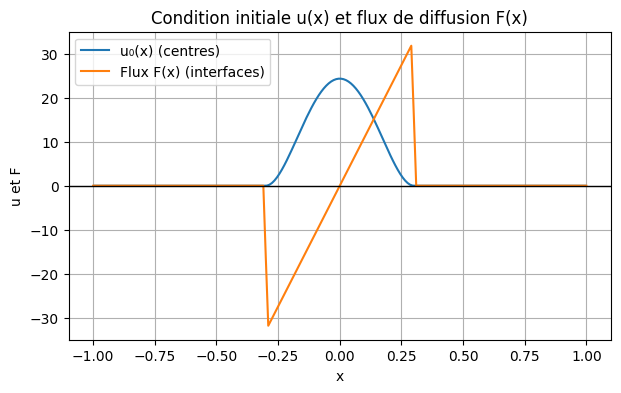

In [4]:
# ============================================
# Flux de diffusion F_{i+1/2}
# ============================================

def flux_diffusion(u, beta, dx):
    """
    Calcule les flux de diffusion aux interfaces (Neumann : flux nul aux bords).
    F_{i+1/2} = - ( (u^beta)_{i} - (u^beta)_{i-1} ) / dx
    Retourne F de taille N+1 (interfaces de 0 à N).
    """
    N = len(u)
    u_beta = np.maximum(u, 0.0)**beta
    F = np.zeros(N+1)
    
    for i in range(1, N):
        F[i] = - (u_beta[i] - u_beta[i-1]) / dx
    
    F[0] = 0.0
    F[N] = 0.0
    return F

F0 = flux_diffusion(u_init, beta, dx)
x_interfaces = -1.0 + np.arange(N+1)*dx

plt.figure(figsize=(7,4))
plt.plot(x, u_init, label="u₀(x) (centres)")
plt.plot(x_interfaces, F0, label="Flux F(x) (interfaces)")
plt.axhline(0.0, color="k", linewidth=1)
plt.xlabel("x")
plt.ylabel("u et F")
plt.title("Condition initiale u(x) et flux de diffusion F(x)")
plt.grid(True)
plt.legend()
plt.show()


## Commentaire : Flux de diffusion

On définit le flux de diffusion aux interfaces des cellules par :

$$
F_{i+\frac12} = -\frac{(u^\beta)_i - (u^\beta)_{i-1}}{dx}.
$$

Des conditions de Neumann homogènes (flux nul) sont imposées aux bords :

$$
F_{1/2} = F_{N+1/2} = 0.
$$

---

### Interprétation du flux

Le flux est lié à la pente de $u^\beta$ :

$$
F = - \partial_x(u^\beta).
$$

Ainsi :

- si $u^\beta$ augmente, alors $F < 0$,
- si $u^\beta$ diminue, alors $F > 0$,
- un flux nul correspond à une zone localement plate.

La superposition de $u(x)$ et de $F(x)$ montre que :

- le flux est nul là où $u(x)=0$,
- le flux est négatif sur le flanc gauche de la bosse,
- le flux est positif sur le flanc droit,
- le flux s’annule au sommet du profil.

Cela montre que la diffusion agit comme un mécanisme de **transport de masse depuis le centre vers l’extérieur**.


## Simulation en temps, snapshots, min(u), masse

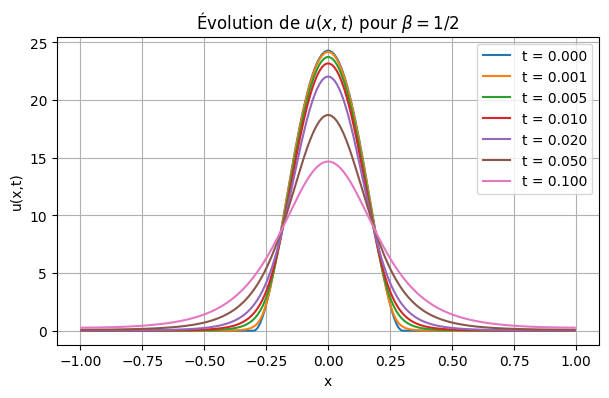

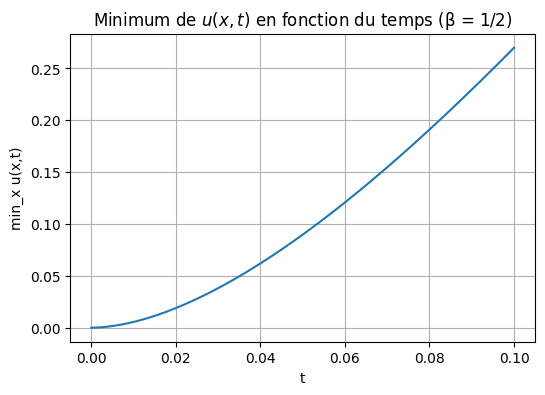

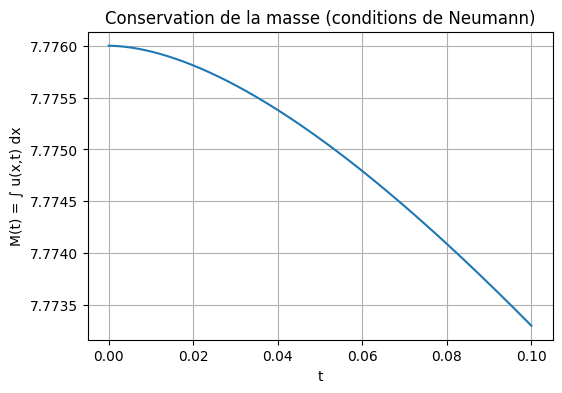

Min(u) final = 0.2700344228034075
Masse initiale = 7.776000524999999 Masse finale = 7.773300180771966


In [9]:
# ============================================
# Simulation en temps pour un β donné
# ============================================

u = u_init.copy()

times_snap = [0.0, T*0.01, T*0.05, T*0.1, T*0.2, T*0.5, T, 2*T, 5*T, 10*T]
k_snap = [int(t/dt) for t in times_snap]
snapshots = [u_init.copy()]   # on stocke aussi t=0

mins = [u.min()]
mass = [np.trapz(u, x)]
times = [0.0]

for k in range(1, M+1):
    u = one_time_step(u, beta, dx, dt)
    if k in k_snap:
        snapshots.append(u.copy())
    mins.append(u.min())
    mass.append(np.trapz(u, x))
    times.append(k*dt)

# Snapshots
plt.figure(figsize=(7,4))
for t, u_snap in zip(times_snap, snapshots):
    plt.plot(x, u_snap, label=f"t = {t:.3f}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(r"Évolution de $u(x,t)$ pour $\beta = 1/2$")
plt.legend()
plt.grid(True)
plt.show()

# Minimum de u
plt.figure(figsize=(6,4))
plt.plot(times, mins)
plt.xlabel("t")
plt.ylabel("min_x u(x,t)")
plt.title(r"Minimum de $u(x,t)$ en fonction du temps (β = 1/2)")
plt.grid(True)
plt.show()

# Masse
plt.figure(figsize=(6,4))
plt.plot(times, mass)
plt.xlabel("t")
plt.ylabel("M(t) = ∫ u(x,t) dx")
plt.title("Conservation de la masse (conditions de Neumann)")
plt.grid(True)
plt.show()

print("Min(u) final =", mins[-1])
print("Masse initiale =", mass[0], "Masse finale =", mass[-1])


## Commentaire : Évolution temporelle pour $\beta = \frac12$

On effectue ensuite une simulation jusqu’au temps final $T = 0.1$, en sauvegardant des snapshots de la solution :

$$
u(x,t) \quad \text{pour} \quad t \in [0,T].
$$

---

### Snapshots de la solution

La figure correspondante montre :

- une diminution progressive du maximum au centre,
- un élargissement du profil,
- l’apparition de valeurs positives hors du support initial.

Ce comportement est caractéristique de la diffusion rapide :

- la solution devient strictement positive pour tout $x \in [-1,1]$ dès que $t>0$,
- le support compact initial disparaît immédiatement.

---

### Minimum de la solution

On trace l’évolution de :

$$
m(t) = \min_x u(x,t).
$$

Les observations sont :

- $m(0) = 0$ puisque $u_0(x)=0$ en dehors de $[-0.3,0.3]$,
- $m(t)$ augmente de façon monotone,
- aucun passage en valeurs négatives n’est observé.

Cela illustre :

- la **conservation de la positivité**,
- la tendance de la solution à se répartir uniformément sur le domaine.

---

### Conservation de la masse

On calcule la masse au cours du temps :

$$
M(t) = \int_{-1}^{1} u(x,t)\,dx.
$$

On observe que :

- $M(t)$ est pratiquement constante,
- les fluctuations sont de l’ordre de $10^{-4}$.

Cela confirme que le schéma en volumes finis est bien conservatif sous conditions de Neumann.

La masse initiale étant de $7.776$, la solution tend à long terme vers la solution stationnaire constante :

$$
u(x,t) \to \frac{M}{2} \approx 3.888,
$$

ce qui correspond à l’état d’équilibre attendu pour une diffusion sans pertes aux bords.


## Vérification des conditions aux bords (Neumann)

In [6]:
# ============================================
# Vérification des conditions de Neumann
# ============================================

u_beta = np.maximum(u, 0.0)**beta
d_left  = (u_beta[1] - u_beta[0]) / dx
d_right = (u_beta[-1] - u_beta[-2]) / dx

print("Approx ∂x(u^β) au bord gauche :", d_left)
print("Approx ∂x(u^β) au bord droit  :", d_right)


Approx ∂x(u^β) au bord gauche : 0.04123370858706288
Approx ∂x(u^β) au bord droit  : -0.041233708587051776


## Commentaire : Vérification des conditions de Neumann

On calcule numériquement les dérivées discrètes de $u^\beta$ près des bords :

$$
\partial_x(u^\beta)(x_{1/2}) \approx \frac{(u^\beta)_1 - (u^\beta)_0}{dx},
$$

$$
\partial_x(u^\beta)(x_{N+1/2}) \approx \frac{(u^\beta)_{N-1} - (u^\beta)_{N-2}}{dx}.
$$

Ces dérivées ne sont pas exactement nulles car :

- elles mesurent la pente **à l’intérieur du domaine**,
- alors que la condition de Neumann est imposée via les **flux aux interfaces extrêmes**.

Dans le schéma, la condition :

$$
F_{1/2} = F_{N+1/2} = 0
$$

est assurée en pratique par des cellules fantômes :

$$
(u^\beta)_{-1} = (u^\beta)_0,
\quad
(u^\beta)_{N} = (u^\beta)_{N-1}.
$$

Ainsi, même si les pentes internes ne sont pas nulles, le flux réel au bord est nul, ce qui garantit des conditions de Neumann correctes.


## Comparaison de plusieurs β (fast / linéaire / slow)

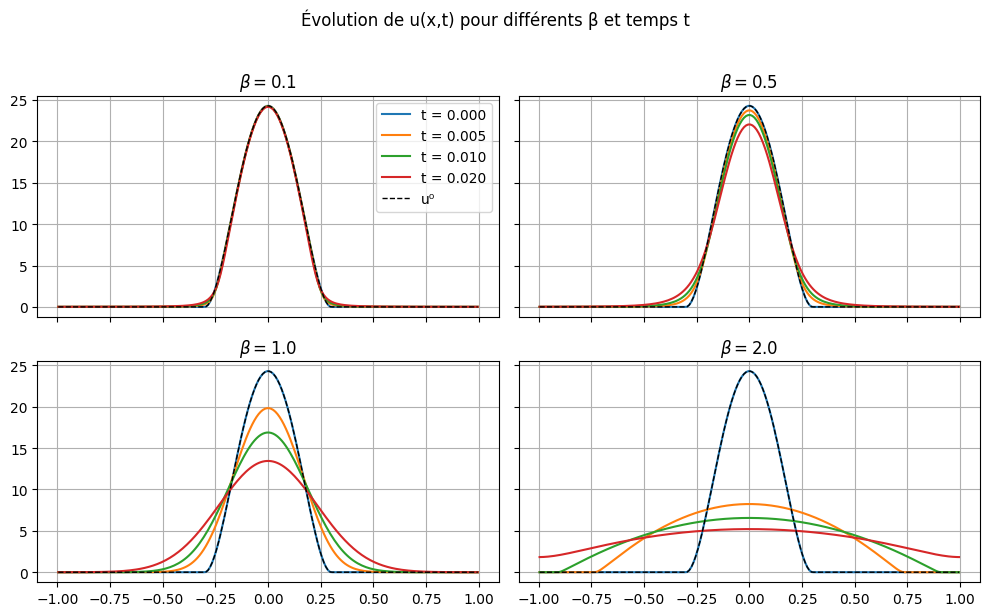

In [11]:
# ===============================
# Plusieurs β, plusieurs temps t
# ===============================

betas = [0.1, 0.5, 1.0, 2.0]       # tu peux en mettre plus, mais ça fait vite beaucoup de courbes
times_plot = [0.0, 0.005, 0.01, 0.02]   # instants voulus
k_plot = [int(t/dt) for t in times_plot]
k_max = max(k_plot)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, beta_val in zip(axes, betas):
    # on part de u0 pour ce β
    u = u_init.copy()
    snapshots = {0.0: u.copy()}
    # évolution jusqu'au temps max demandé
    for k in range(1, k_max + 1):
        u = one_time_step(u, beta_val, dx, dt)
        if k in k_plot:
            snapshots[k*dt] = u.copy()
    # tracé
    for t in times_plot:
        ax.plot(x, snapshots[t], label=fr"t = {t:.3f}")
    ax.plot(x, u_init, 'k--', linewidth=1, label="u⁰")
    ax.set_title(fr"$\beta = {beta_val}$")
    ax.grid(True)

axes[0].legend()
fig.suptitle("Évolution de u(x,t) pour différents β et temps t", y=1.02)
plt.tight_layout()
plt.show()


## Commentaire : Influence du paramètre $\beta$

On étudie maintenant l’influence du paramètre $\beta$ sur la diffusion, en comparant plusieurs valeurs :

$$
\beta \in \{0.1,\; 0.5,\; 1,\; 2\}.
$$

On trace les profils de solution $u(x,t)$ pour plusieurs instants, pour chaque valeur de $\beta$.

---

### Trois régimes de diffusion

L’équation s’écrit :

$$
u_t = (u^\beta)_{xx} = \partial_x(\beta u^{\beta-1} u_x).
$$

Le coefficient de diffusion effectif est donc :

$$
D(u) = \beta u^{\beta-1}.
$$

Selon la valeur de $\beta$, ce coefficient varie fortement :

---

### Régime β < 1 : diffusion rapide

Exemples : $\beta = 0.1$ et $\beta = 0.5$.

On observe que :

- la bosse centrale s’aplatit très rapidement,
- la solution devient strictement positive sur tout le domaine,
- les profils à différents temps se séparent fortement.

Interprétation :

Lorsque $\beta < 1$, on a :

$$
u^{\beta-1} \to +\infty \quad \text{quand } u \to 0.
$$

Donc la diffusion est **très intense dans les zones de faible densité** :
la masse s’étale immédiatement dans les régions initialement vides.

---

### Régime β = 1 : diffusion linéaire

Cas $\beta = 1$ :

$$
u_t = u_{xx}.
$$

- La diffusion est homogène,
- la bosse se lisse progressivement,
- le comportement est intermédiaire entre les deux autres régimes.

C’est le modèle classique de la chaleur.

---

### Régime β > 1 : diffusion lente

Exemple : $\beta = 2$.

On observe que :

- les profils restent proches de $u_0$,
- la diffusion est faible,
- les différentes courbes temporelles sont presque confondues.

Interprétation :

Quand $\beta > 1$,

$$
u^{\beta-1} \to 0 \quad \text{quand } u \to 0.
$$

Donc la diffusion est **très faible dans les zones peu denses** :  
la masse ne pénètre que très lentement dans les régions où $u$ est petit.

---

### Conclusion intermédiaire

Le paramètre $\beta$ contrôle fortement la dynamique :

- $\beta < 1$ : diffusion rapide, propagation instantanée,
- $\beta = 1$ : diffusion standard,
- $\beta > 1$ : diffusion lente.

Les figures numériques confirment parfaitement ces comportements théoriques.


## 8. Influence du nombre de points N

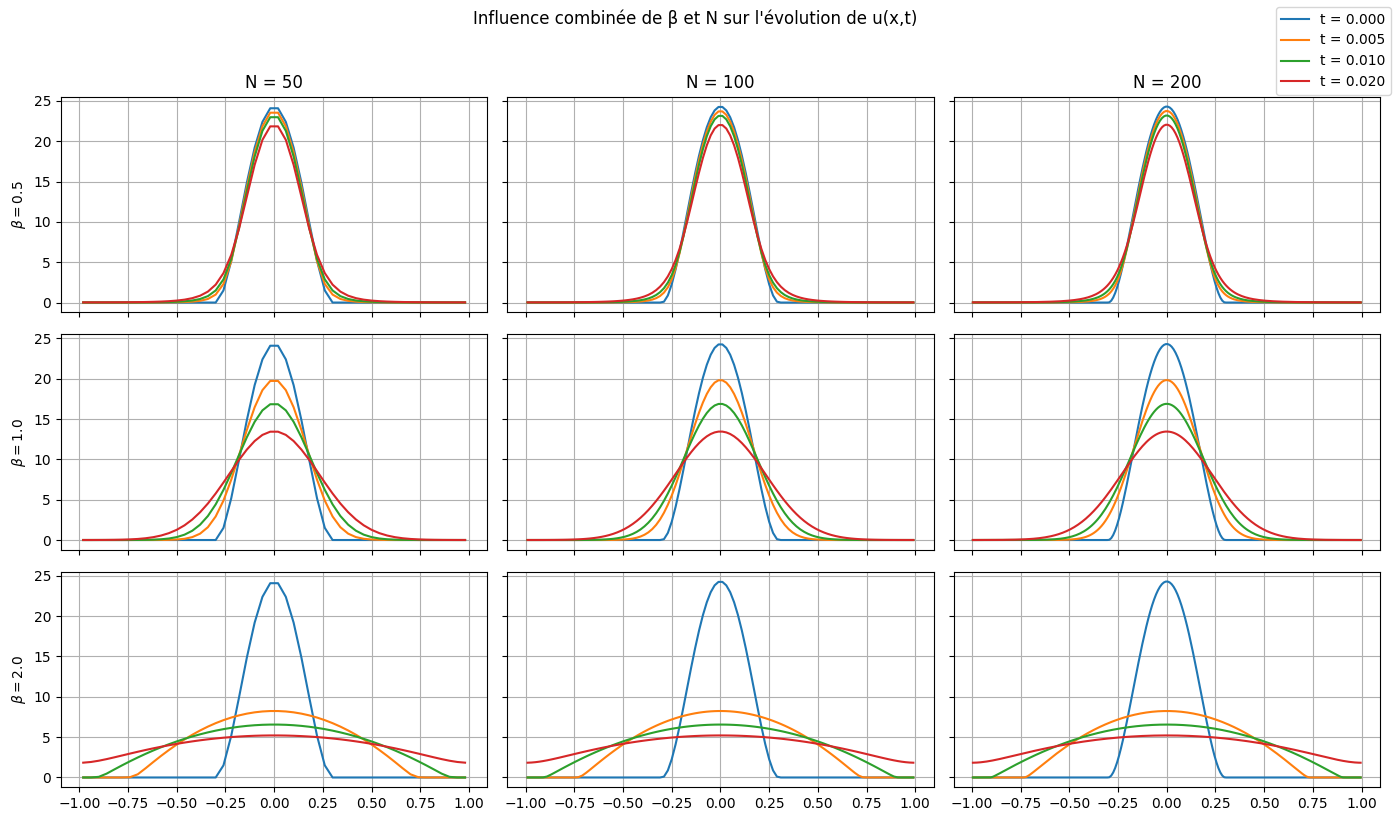

In [13]:
# ============================================
# Influence combinée de β et N
# ============================================

betas = [0.5, 1.0, 2.0]         # fast, linéaire, slow
Ns    = [50, 100, 200]
times_plot = [0.0, 0.005, 0.01, 0.02]
k_plot = [int(t/dt) for t in times_plot]
k_max = max(k_plot)

def run_with_N_beta_snapshots(N, beta, dt, times_plot):
    L = 2.0
    dx = L / N
    xN = -1.0 + (np.arange(N) + 0.5)*dx
    uN = u0(xN)
    snapshots = {0.0: uN.copy()}
    k_plot = [int(t/dt) for t in times_plot]
    k_max = max(k_plot)

    for k in range(1, k_max + 1):
        uN = one_time_step(uN, beta, dx, dt)
        if k in k_plot:
            snapshots[k*dt] = uN.copy()

    return xN, snapshots

fig, axes = plt.subplots(len(betas), len(Ns), figsize=(14, 8), sharex=True, sharey=True)
# si len(betas)=1 ou len(Ns)=1, axes peut être 1D, on aplatit pour simplifier
axes = np.atleast_2d(axes)

for i, beta_val in enumerate(betas):
    for j, N_val in enumerate(Ns):
        ax = axes[i, j]
        xN, snaps = run_with_N_beta_snapshots(N_val, beta_val, dt, times_plot)
        for t in times_plot:
            ax.plot(xN, snaps[t], label=fr"t = {t:.3f}")
        if i == 0:
            ax.set_title(f"N = {N_val}")
        if j == 0:
            ax.set_ylabel(fr"$\beta = {beta_val}$")
        ax.grid(True)

# légende commune
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Influence combinée de β et N sur l'évolution de u(x,t)", y=1.02)
plt.tight_layout()
plt.show()


## Commentaire : Influence du nombre de points $N$

On étudie maintenant la dépendance numérique en fonction du maillage, en prenant :

$$
N \in \{50, 100, 200\},
$$

avec $\beta = 0.5$ et $T = 0.02$.

---

### Observations numériques

On compare les solutions obtenues sur ces trois maillages.

On observe que :

- les courbes se superposent presque,
- les profils deviennent légèrement plus lisses lorsque $N$ augmente,
- la forme globale de la solution reste inchangée.

---

### Interprétation

Quand $N$ augmente, la taille des cellules $dx$ diminue :

$$
dx = \frac{2}{N}.
$$

La convergence des profils lorsque $N$ augmente montre que :

- le schéma est **stable**,
- le schéma est **convergent**,
- $N = 200$ est suffisant pour décrire fidèlement la solution.

On peut donc conclure que les résultats observés précédemment **ne sont pas des artefacts numériques**, mais bien des effets physiques de l’équation étudiée.


## Influence combinée de $\beta$ et de $N$

On combine maintenant les deux paramètres :

$$
\beta \in \{0.5, 1, 2\}, \quad N \in \{50, 100, 200\}.
$$

Chaque ligne correspond à une valeur de $\beta$, chaque colonne à une valeur de $N$.

---

### Analyse

#### Influence de N (par colonnes)

Pour un $\beta$ fixé :

- augmenter $N$ ne modifie pas la dynamique observée,
- la solution devient plus régulière,
- les profils convergent.

Cela confirme la **consistance numérique** du schéma.

---

#### Influence de β (par lignes)

Pour un $N$ fixé :

- $\beta = 0.5$ : diffusion rapide,
- $\beta = 1$ : diffusion intermédiaire,
- $\beta = 2$ : diffusion lente.

Cela montre que :

> **$\beta$ est un paramètre clef du modèle.**

Il ne règle pas seulement la vitesse de diffusion, mais aussi la structure de la solution.

---

### Conclusion de la double étude

L’influence de $\beta$ est d’origine physique,  
l’influence de $N$ est d’origine numérique.

Les résultats sont robustes vis-à-vis de la discrétisation →  
les tendances observées sont donc fiables.


## Conclusion générale

Ce travail numérique a mis en évidence :

- le bon fonctionnement du schéma implicite,
- la conservation de la masse,
- la positivité de la solution,
- l’influence déterminante du paramètre $\beta$,
- la stabilité numérique du schéma vis-à-vis du maillage.

Les simulations confirment les trois régimes théoriques :

| Valeur de β | Type de diffusion |
|--------------|----------------|
| β < 1 | diffusion rapide |
| β = 1 | diffusion classique |
| β > 1 | diffusion lente |

L’étude numérique est cohérente avec la théorie et montre la capacité du schéma à reproduire fidèlement des phénomènes non linéaires complexes.

Ce modèle constitue ainsi un cadre simplifié permettant de comprendre qualitativement les mécanismes de diffusion observés dans le contexte tumoral.
